In [1]:
import pandas as pd
import numpy as np
import pickle
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
import torch
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder


In [2]:
warnings.filterwarnings('ignore')
print(f"XGBoost version: {xgb.__version__}")
print(f"CUDA avaiable: {torch.cuda.is_available}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    TREE_METHOD = 'hist'
    DEVICE = 'cuda'
else:
    TREE_METHOD = 'hist'
    DEVICE = 'cpu'
    
print(f"training on: {DEVICE}")

XGBoost version: 3.2.0
CUDA avaiable: <function is_available at 0x000001AD3F5EB3D0>
GPU: NVIDIA GeForce RTX 5080
training on: cuda


In [3]:
train_df = pd.read_parquet("train_df.parquet")
test_df = pd.read_parquet("test_df.parquet")

with open('feature_list.pkl', 'rb') as f:
    feature_info = pickle.load(f)
    
ALL_FEATURES = feature_info['ALL_FEATURES']
TARGET = feature_info['TARGET']


X_train = train_df[ALL_FEATURES].copy()
y_train = train_df[TARGET].copy()
X_test = test_df[ALL_FEATURES].copy()
y_test = test_df[TARGET].copy()

cat_cols = [f for f in ALL_FEATURES if X_train[f].dtype.kind == 'O' 
            or pd.api.types.is_string_dtype(X_train[f])]
print(f"Categorical features: {len(cat_cols)}")
print(f"Categorical columns:  {cat_cols}")

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_test[col]]).astype(str).fillna('UNKNOWN')
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str).fillna('UNKNOWN')).astype(int)
    X_test[col]  = le.transform(X_test[col].astype(str).fillna('UNKNOWN')).astype(int)
    label_encoders[col] = le

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target: {TARGET}")
print(f"Feature: {len(ALL_FEATURES)}")
print(f"\nTest storms")
print(test_df['floodEvent'].value_counts())

Categorical features: 7
Categorical columns:  ['occupancyType', 'ratedFloodZone', 'floodZoneCurrent', 'causeOfDamage', 'storm_intensity_cat', 'prop_wind_exposure', 'state']
Train: (720526, 49), Test: (189549, 49)
Target: buildingDamageAmount_2024_capped
Feature: 49

Test storms
floodEvent
Hurricane Sandy    135455
Hurricane Ian       38035
Hurricane Ivan      16059
Name: count, dtype: int64


In [4]:
print(X_train.dtypes.unique())
print(X_train['occupancyType'].dtype)
print(type(X_train['occupancyType'].iloc[0]))

[dtype('float64') dtype('int64')]
int64
<class 'numpy.int64'>


In [5]:
base = xgb.XGBRegressor(
    n_estimators = 1000,
    learning_rate = 0.05,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    tree_method = TREE_METHOD,
    device =DEVICE,
    random_state =  67,
    early_stopping_rounds = 50,
    eval_metric = 'rmse',
)

print("training XGBoost base model")
base.fit(
    X_train, y_train,
    eval_set = [(X_train, y_train),(X_test,y_test)],
    verbose = 50
)
print("baseline models complete")

training XGBoost base model
[0]	validation_0-rmse:105412.04725	validation_1-rmse:121604.07512
[50]	validation_0-rmse:70034.62140	validation_1-rmse:115055.65624
[100]	validation_0-rmse:66062.99189	validation_1-rmse:114772.35593
[150]	validation_0-rmse:64184.09361	validation_1-rmse:115038.94283
[163]	validation_0-rmse:63789.70486	validation_1-rmse:115169.65952
baseline models complete


In [6]:
y_pred = base.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae =  mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("── Baseline Model Performance ──────────────────")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE:  ${mae:,.0f}")
print(f"R²:   {r2:.4f}")

test_df['y_pred'] = y_pred
print("\n── Per-Storm Performance ───────────────────────")
for storm in test_df['floodEvent'].unique():
    mask = test_df['floodEvent'] == storm
    s_rmse = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
    s_mae = mean_absolute_error(y_test[mask], y_pred[mask])
    s_r2   = r2_score(y_test[mask], y_pred[mask])
    print(f"{storm:<25} RMSE: ${s_rmse:>10,.0f}  MAE: ${s_mae:>10,.0f}  R²: {s_r2:.4f}")

── Baseline Model Performance ──────────────────
RMSE: $114,599
MAE:  $59,290
R²:   0.1210

── Per-Storm Performance ───────────────────────
Hurricane Sandy           RMSE: $    94,637  MAE: $    53,205  R²: 0.0279
Hurricane Ian             RMSE: $   152,066  MAE: $    73,591  R²: 0.1720
Hurricane Ivan            RMSE: $   157,165  MAE: $    76,748  R²: 0.1909


── Top 20 Features ─────────────────────────────
                           feature  importance
           hurdat2_min_pressure_mb    0.141689
             buildingPropertyValue    0.091222
                         longitude    0.076967
            hurdat2_max_wind_speed    0.069725
                   elevated_binary    0.056981
                   obstructionType    0.049365
    totalBuildingInsuranceCoverage    0.037924
           buildingReplacementCost    0.033805
                             state    0.023122
                        yearOfLoss    0.021685
                  prop_max_wind_kt    0.021227
              building_age_at_loss    0.020481
                  post_firm_binary    0.019625
                     causeOfDamage    0.019431
                prop_wind_exposure    0.018703
             prop_dist_to_track_nm    0.018006
                       policyCount    0.017127
                     occupancyType    0.016391
numberOfFloorsInTheInsuredBuilding    0.015326
           

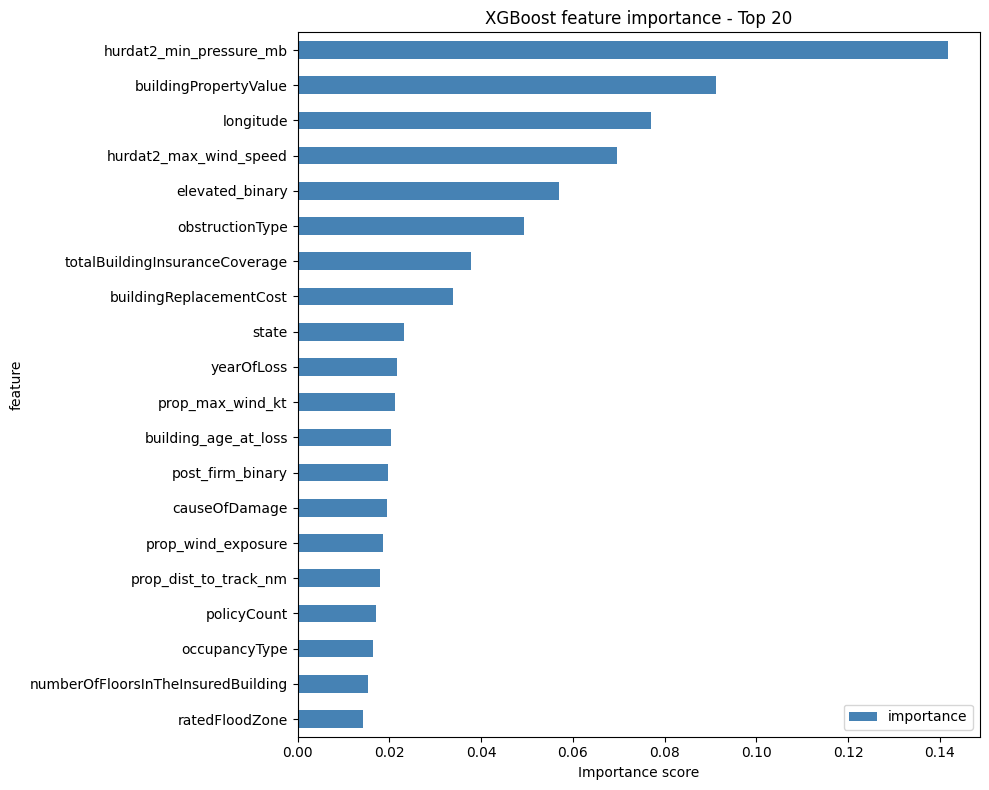

Feature importance saved ✅


In [7]:
importance_df = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': base.feature_importances_
}).sort_values('importance',ascending=False)

print("── Top 20 Features ─────────────────────────────")
print(importance_df.head(20).to_string(index=False))


fig, ax = plt.subplots(figsize= (10,8))
importance_df.head(20).sort_values("importance").plot.barh(
    x='feature', y='importance', ax=ax, color="steelblue"
)

ax.set_title("XGBoost feature importance - Top 20")
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig("feature importance.png", dpi=150)
plt.show() 
print("Feature importance saved ✅")

In [8]:
base.save_model('hurricane_severity_model.json')

print("Model saved to hurricane_severity_model.json ✅")
print(f"\nFinal metrics:")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  MAE:  ${mae:,.0f}")
print(f"  R²:   {r2:.4f}")

Model saved to hurricane_severity_model.json ✅

Final metrics:
  RMSE: $114,599
  MAE:  $59,290
  R²:   0.1210


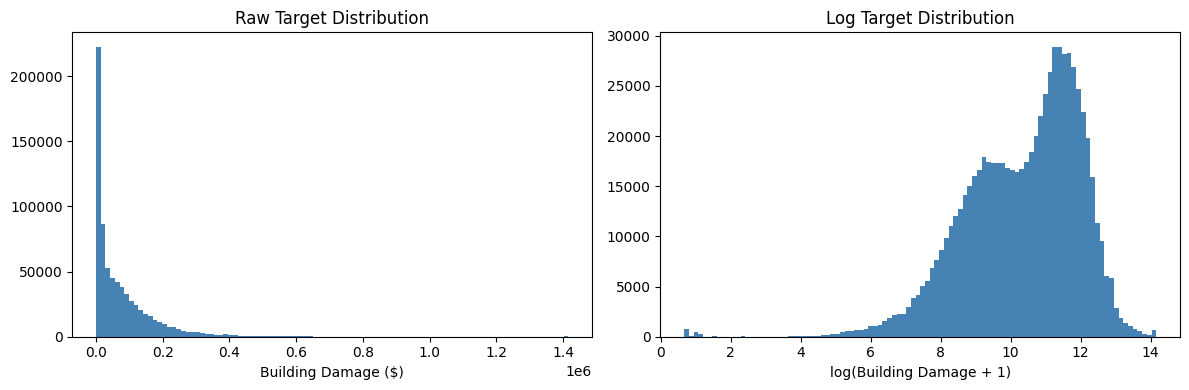

Skewness: 4.06
% of claims under $50k: 53.6%
% of claims under $100k: 72.5%


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Raw Target Distribution')
axes[0].set_xlabel('Building Damage ($)')
 
axes[1].hist(np.log1p(y_train), bins=100, color='steelblue', edgecolor='none')
axes[1].set_title('Log Target Distribution')
axes[1].set_xlabel('log(Building Damage + 1)')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

print(f"Skewness: {y_train.skew():.2f}")
print(f"% of claims under $50k: {(y_train < 50000).mean()*100:.1f}%")
print(f"% of claims under $100k: {(y_train < 100000).mean()*100:.1f}%")

In [10]:
cat_cols = [f for f in ALL_FEATURES if pd.api.types.is_string_dtype(X_train[f])]
print(f"Encoding: {cat_cols}")

from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_test[col]]).astype(str).fillna('UNKNOWN')
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str).fillna('UNKNOWN')).astype(int)
    X_test[col]  = le.transform(X_test[col].astype(str).fillna('UNKNOWN')).astype(int)
    label_encoders[col] = le

print(f"String cols remaining: {[f for f in ALL_FEATURES if pd.api.types.is_string_dtype(X_train[f])]}")

Encoding: []
String cols remaining: []


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load
X_train = train_df[ALL_FEATURES].copy()
y_train = train_df[TARGET].copy()
X_test  = test_df[ALL_FEATURES].copy()
y_test  = test_df[TARGET].copy()

# Encode immediately after load
cat_cols = [f for f in ALL_FEATURES if pd.api.types.is_string_dtype(X_train[f])]
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_test[col]]).astype(str).fillna('UNKNOWN')
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str).fillna('UNKNOWN')).astype(int)
    X_test[col]  = le.transform(X_test[col].astype(str).fillna('UNKNOWN')).astype(int)
    label_encoders[col] = le
print(f"Encoded {len(cat_cols)} columns. String cols remaining: {[f for f in ALL_FEATURES if pd.api.types.is_string_dtype(X_train[f])]}")

# Log transform
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

# Split
X_tr, X_val, y_tr_raw, y_val_raw = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=67
)
print(f"Train: {X_tr.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Encoded 7 columns. String cols remaining: []
X_train: (720526, 49), y_train: (720526,)
Train: (648473, 49), Val: (72053, 49), Test: (189549, 49)


In [12]:
X_tr, X_val, y_tr_raw, y_val_raw = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=67
)

tuned_model = xgb.XGBRegressor(
    n_estimators          = 5000,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 10,
    tree_method           = TREE_METHOD,
    device                = DEVICE,
    random_state          = 67,
    early_stopping_rounds = 50,
    eval_metric           = 'rmse',
)

print("Training raw target model with validation split...")
tuned_model.fit(
    X_tr, y_tr_raw,
    eval_set=[(X_tr, y_tr_raw), (X_val, y_val_raw)],
    verbose=100
)

print(f"\nBest iteration: {tuned_model.best_iteration}")
print(f"Best score:     {tuned_model.best_score:.4f}")

Training raw target model with validation split...
[0]	validation_0-rmse:105327.13547	validation_1-rmse:106226.24616
[100]	validation_0-rmse:66006.44665	validation_1-rmse:67278.55291
[200]	validation_0-rmse:62618.97002	validation_1-rmse:64735.41538
[300]	validation_0-rmse:60668.56834	validation_1-rmse:63441.10631
[400]	validation_0-rmse:59311.49869	validation_1-rmse:62720.57188
[500]	validation_0-rmse:58212.67217	validation_1-rmse:62176.92348
[600]	validation_0-rmse:57183.12119	validation_1-rmse:61703.37759
[700]	validation_0-rmse:56347.14128	validation_1-rmse:61326.42432
[800]	validation_0-rmse:55491.67198	validation_1-rmse:60961.18150
[900]	validation_0-rmse:54793.91264	validation_1-rmse:60659.14801
[1000]	validation_0-rmse:54148.45806	validation_1-rmse:60401.66976
[1100]	validation_0-rmse:53576.22084	validation_1-rmse:60198.28980
[1200]	validation_0-rmse:52939.47468	validation_1-rmse:60012.12517
[1300]	validation_0-rmse:52459.44779	validation_1-rmse:59852.72221
[1400]	validation_0-r

In [13]:
y_pred = tuned_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("── Final Model Performance ─────────────────────")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE:  ${mae:,.0f}")
print(f"R²:   {r2:.4f}")

print("\n── Per-Storm Performance ───────────────────────")
for storm in test_df['floodEvent'].unique():
    mask   = (test_df['floodEvent'] == storm).values
    s_rmse = np.sqrt(mean_squared_error(y_test.values[mask], y_pred[mask]))
    s_mae  = mean_absolute_error(y_test.values[mask], y_pred[mask])
    s_r2   = r2_score(y_test.values[mask], y_pred[mask])
    n      = mask.sum()
    print(f"{storm:<25} n={n:>6,}  RMSE: ${s_rmse:>10,.0f}  MAE: ${s_mae:>9,.0f}  R²: {s_r2:.4f}")

# Save
tuned_model.save_model('hurricane_severity_model_v2.json')
print("\nModel saved ✅")

── Final Model Performance ─────────────────────
RMSE: $117,636
MAE:  $61,901
R²:   0.0739

── Per-Storm Performance ───────────────────────
Hurricane Sandy           n=135,455  RMSE: $    99,128  MAE: $   56,442  R²: -0.0666
Hurricane Ian             n=38,035  RMSE: $   156,711  MAE: $   76,257  R²: 0.1206
Hurricane Ivan            n=16,059  RMSE: $   149,289  MAE: $   73,948  R²: 0.2700

Model saved ✅


HYPER PARAM TUNING

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define parameter space
param_dist = {
    'n_estimators':      [1000, 2000, 3000, 5000],
    'learning_rate':     uniform(0.01, 0.09),
    'max_depth':         randint(4, 10),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'min_child_weight':  randint(5, 50),
    'gamma':             uniform(0, 0.5),
    'reg_alpha':         uniform(0, 1),
    'reg_lambda':        uniform(0.5, 2),
}

# Base estimator
xgb_base = xgb.XGBRegressor(
    tree_method = TREE_METHOD,
    device      = DEVICE,
    random_state= 67,
    eval_metric = 'rmse',
)

print("Running randomized search")
print("15 iterations × 3 folds = 45 fits")

search = RandomizedSearchCV(
    xgb_base,
    param_distributions = param_dist,
    n_iter              = 15,
    cv                  = 3,
    scoring             = 'neg_root_mean_squared_error',
    random_state        = 67,
    verbose             = 2,
    n_jobs              = 1
)

search.fit(X_tr, y_tr_raw)

print(f"\nBest params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: ${-search.best_score_:,.0f}")

Running randomized search
15 iterations × 3 folds = 45 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END colsample_bytree=0.8183405719739915, gamma=0.4294283052956795, learning_rate=0.07173033279099211, max_depth=5, min_child_weight=32, n_estimators=5000, reg_alpha=0.7903301744630767, reg_lambda=0.7968677463106788, subsample=0.9024541167393525; total time=  14.1s
[CV] END colsample_bytree=0.8183405719739915, gamma=0.4294283052956795, learning_rate=0.07173033279099211, max_depth=5, min_child_weight=32, n_estimators=5000, reg_alpha=0.7903301744630767, reg_lambda=0.7968677463106788, subsample=0.9024541167393525; total time=  13.7s
[CV] END colsample_bytree=0.8183405719739915, gamma=0.4294283052956795, learning_rate=0.07173033279099211, max_depth=5, min_child_weight=32, n_estimators=5000, reg_alpha=0.7903301744630767, reg_lambda=0.7968677463106788, subsample=0.9024541167393525; total time=  13.6s
[CV] END colsample_bytree=0.9675244740331718, gamma=0.414629407401737

post hyper param v1

In [15]:
tuned_model = xgb.XGBRegressor(
    **search.best_params_,
    tree_method           = TREE_METHOD,
    device                = DEVICE,
    random_state          = 67,
    early_stopping_rounds = 100,
    eval_metric           = 'rmse',
)

print("Training tuned model...")
tuned_model.fit(
    X_tr, y_tr_raw,
    eval_set=[(X_tr, y_tr_raw), (X_val, y_val_raw)],
    verbose=200
)

print(f"\nBest iteration: {tuned_model.best_iteration}")
print(f"Best score:     ${tuned_model.best_score:,.0f}")

# Evaluate
y_pred_tuned = tuned_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae  = mean_absolute_error(y_test, y_pred_tuned)
r2   = r2_score(y_test, y_pred_tuned)

print("\n── Tuned Model Performance ─────────────────────")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE:  ${mae:,.0f}")
print(f"R²:   {r2:.4f}")

print("\n── Per-Storm Performance ───────────────────────")
for storm in test_df['floodEvent'].unique():
    mask   = (test_df['floodEvent'] == storm).values
    s_rmse = np.sqrt(mean_squared_error(y_test.values[mask], y_pred_tuned[mask]))
    s_mae  = mean_absolute_error(y_test.values[mask], y_pred_tuned[mask])
    s_r2   = r2_score(y_test.values[mask], y_pred_tuned[mask])
    n      = mask.sum()
    print(f"{storm:<25} n={n:>6,}  RMSE: ${s_rmse:>10,.0f}  MAE: ${s_mae:>9,.0f}  R²: {s_r2:.4f}")

# Save tuned model
tuned_model.save_model('hurricane_severity_model_tuned.json')
print("\nTuned model saved ✅")

Training tuned model...
[0]	validation_0-rmse:105370.23446	validation_1-rmse:106296.18698
[200]	validation_0-rmse:56034.19478	validation_1-rmse:60880.35435
[400]	validation_0-rmse:52803.50971	validation_1-rmse:59649.44601
[600]	validation_0-rmse:50565.94067	validation_1-rmse:58893.42596
[800]	validation_0-rmse:48605.99739	validation_1-rmse:58421.78377
[1000]	validation_0-rmse:47057.60734	validation_1-rmse:58112.79405
[1200]	validation_0-rmse:45605.61736	validation_1-rmse:57930.33011
[1400]	validation_0-rmse:44456.91767	validation_1-rmse:57779.15729
[1600]	validation_0-rmse:43401.89809	validation_1-rmse:57651.31737
[1800]	validation_0-rmse:42421.57890	validation_1-rmse:57589.24176
[1999]	validation_0-rmse:41546.96877	validation_1-rmse:57512.25363

Best iteration: 1970
Best score:     $57,509

── Tuned Model Performance ─────────────────────
RMSE: $117,687
MAE:  $62,053
R²:   0.0730

── Per-Storm Performance ───────────────────────
Hurricane Sandy           n=135,455  RMSE: $    99,128  

Hyper param tuning v2

In [16]:
param_dist_v2 = {
    'n_estimators':     [2000, 3000, 5000],
    'learning_rate':    uniform(0.01, 0.05),
    'max_depth':        randint(6, 12),
    'subsample':        uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'min_child_weight': randint(5, 30),
    'gamma':            uniform(0, 0.3),
    'reg_alpha':        uniform(0, 0.5),
    'reg_lambda':       uniform(1.0, 1.5),
}

search_v2 = RandomizedSearchCV(
    xgb_base,
    param_distributions = param_dist_v2,
    n_iter              = 20,
    cv                  = 3,
    scoring             = 'neg_root_mean_squared_error',
    random_state        = 42,
    verbose             = 2,
    n_jobs              = 1
)

search_v2.fit(X_tr, y_tr_raw)

print(f"\nBest params:")
for k, v in search_v2.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: ${-search_v2.best_score_:,.0f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.8123620356542087, gamma=0.2852142919229748, learning_rate=0.046599697090570255, max_depth=10, min_child_weight=25, n_estimators=5000, reg_alpha=0.22291637642679557, reg_lambda=1.1499623737270044, subsample=0.8377746675897602; total time=  41.4s
[CV] END colsample_bytree=0.8123620356542087, gamma=0.2852142919229748, learning_rate=0.046599697090570255, max_depth=10, min_child_weight=25, n_estimators=5000, reg_alpha=0.22291637642679557, reg_lambda=1.1499623737270044, subsample=0.8377746675897602; total time=  44.0s
[CV] END colsample_bytree=0.8123620356542087, gamma=0.2852142919229748, learning_rate=0.046599697090570255, max_depth=10, min_child_weight=25, n_estimators=5000, reg_alpha=0.22291637642679557, reg_lambda=1.1499623737270044, subsample=0.8377746675897602; total time=  45.1s
[CV] END colsample_bytree=0.8001125833417065, gamma=0.04286004537658223, learning_rate=0.042544423647442646, max_depth=1

KeyboardInterrupt: 

In [ ]:
final_model = xgb.XGBRegressor(
    **search_v2.best_params_,
    tree_method           = TREE_METHOD,
    device                = DEVICE,
    random_state          = 67,
    early_stopping_rounds = 100,
    eval_metric           = 'rmse',
)

print("Training final model...")
final_model.fit(
    X_tr, y_tr_raw,
    eval_set=[(X_tr, y_tr_raw), (X_val, y_val_raw)],
    verbose=200
)

print(f"\nBest iteration: {final_model.best_iteration}")

y_pred_final = final_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae  = mean_absolute_error(y_test, y_pred_final)
r2   = r2_score(y_test, y_pred_final)

print("\n── Final Tuned Model Performance ───────────────")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE:  ${mae:,.0f}")
print(f"R²:   {r2:.4f}")

print("\n── Per-Storm Performance ────────────────────────")
for storm in test_df['floodEvent'].unique():
    mask   = (test_df['floodEvent'] == storm).values
    s_rmse = np.sqrt(mean_squared_error(y_test.values[mask], y_pred_final[mask]))
    s_mae  = mean_absolute_error(y_test.values[mask], y_pred_final[mask])
    s_r2   = r2_score(y_test.values[mask], y_pred_final[mask])
    n      = mask.sum()
    print(f"{storm:<25} n={n:>6,}  RMSE: ${s_rmse:>10,.0f}  MAE: ${s_mae:>9,.0f}  R²: {s_r2:.4f}")

final_model.save_model('hurricane_severity_model_final.json')
print("\nFinal model saved ✅")

Training final model...
[0]	validation_0-rmse:105951.27603	validation_1-rmse:106895.70438
[200]	validation_0-rmse:51627.16720	validation_1-rmse:59747.60074
[400]	validation_0-rmse:47291.47336	validation_1-rmse:58393.56688
[600]	validation_0-rmse:44521.67885	validation_1-rmse:57797.16448
[800]	validation_0-rmse:42139.62049	validation_1-rmse:57352.75721
[1000]	validation_0-rmse:40241.14741	validation_1-rmse:57039.83685
[1200]	validation_0-rmse:38654.98680	validation_1-rmse:56828.40443
[1400]	validation_0-rmse:37285.83312	validation_1-rmse:56685.45328
[1600]	validation_0-rmse:36038.03104	validation_1-rmse:56608.32957
[1800]	validation_0-rmse:34915.13005	validation_1-rmse:56501.92744
[1999]	validation_0-rmse:33894.82471	validation_1-rmse:56414.70787

Best iteration: 1999

── Final Tuned Model Performance ───────────────
RMSE: $118,541
MAE:  $62,305
R²:   0.0595

── Per-Storm Performance ────────────────────────
Hurricane Sandy           n=135,455  RMSE: $    99,537  MAE: $   56,932  R²: -0

MODEL SLIMMING

In [19]:
import os
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
 
MODEL_PATH = "hurricane_severity_model_final.json"

if os.path.exists(MODEL_PATH):
    backup = "hurricane_severity_model_final_BACKUP.json"
    if not os.path.exists(backup):
        import shutil
        shutil.copy(MODEL_PATH, backup)
        size_mb = os.path.getsize(backup) / 1e6
        print(f"Backed up old model -> {backup} ({size_mb:.1f} MB)")
        
old_model = xgb.XGBRegressor()
old_model.load_model(MODEL_PATH)
y_old = old_model.predict(X_test)
old_r2   = r2_score(y_test, y_old)
old_rmse = np.sqrt(mean_squared_error(y_test, y_old))
old_mae  = mean_absolute_error(y_test, y_old)
old_size = os.path.getsize(MODEL_PATH) / 1e6
print(f"\nOLD model: R²={old_r2:.4f}  RMSE=${old_rmse:,.0f}  MAE=${old_mae:,.0f}  size={old_size:.1f}MB")


slim_params = dict(
    n_estimators        = 3000,        # high cap; early stopping decides actual count
    max_depth           = 5,           # was 10 — the main size driver
    learning_rate       = 0.03,        # lower LR + more trees = smoother fit
    subsample           = 0.8,         # row sampling -> regularization
    colsample_bytree    = 0.8,         # feature sampling -> regularization
    min_child_weight    = 5,           # harder to make tiny overfit leaves
    gamma               = 0.5,         # min loss reduction to split
    reg_alpha           = 0.5,         # L1
    reg_lambda          = 2.0,         # L2
    tree_method         = TREE_METHOD,
    device              = DEVICE,
    random_state        = 67,
    early_stopping_rounds = 100,
    eval_metric         = 'rmse',
)

print("\nTraining slim model...")
slim_model = xgb.XGBRegressor(**slim_params)
slim_model.fit(
    X_tr, y_tr_raw,
    eval_set=[(X_tr, y_tr_raw), (X_val, y_val_raw)],
    verbose=200,
)
print(f"Best iteration: {slim_model.best_iteration} (of {slim_params['n_estimators']} cap)")
 
# --- NEW model performance ---------------------------------------------------
y_new = np.clip(slim_model.predict(X_test), 0, None)
new_r2   = r2_score(y_test, y_new)
new_rmse = np.sqrt(mean_squared_error(y_test, y_new))
new_mae  = mean_absolute_error(y_test, y_new)
 
# Save then measure size
slim_model.save_model(MODEL_PATH)
new_size = os.path.getsize(MODEL_PATH) / 1e6
 
print("\n── OLD vs NEW ─────────────────────────────────────────────")
print(f"            {'OLD':>14} {'NEW':>14}")
print(f"R²          {old_r2:>14.4f} {new_r2:>14.4f}")
print(f"RMSE        {old_rmse:>13,.0f}  {new_rmse:>13,.0f}")
print(f"MAE         {old_mae:>13,.0f}  {new_mae:>13,.0f}")
print(f"Size (MB)   {old_size:>14.1f} {new_size:>14.1f}")
 
print("\n── Per-Storm Test R² (new model) ──────────────────────────")
for storm in test_df['floodEvent'].unique():
    mask = (test_df['floodEvent'] == storm).values
    s_r2 = r2_score(y_test.values[mask], y_new[mask])
    print(f"  {storm:<22} n={mask.sum():>6,}  R²: {s_r2:.4f}")
 
# --- Decision guidance -------------------------------------------------------
print("\n" + "="*60)
if new_size < 100 and new_r2 >= old_r2 - 0.01:
    print(f"✅ Under 100MB ({new_size:.1f}MB) and R² held/improved. Good to push.")
    print("   NOW re-run: calibration cell -> percentile cell -> save cell.")
elif new_size >= 100:
    print(f"⚠️  Still {new_size:.1f}MB. Lower max_depth to 4 and retrain.")
else:
    print(f"⚠️  R² dropped ({old_r2:.4f} -> {new_r2:.4f}). Consider max_depth=6")
    print("   or a slightly higher learning_rate. Re-run before accepting.")
 
# Make slim_model the active model variable for the downstream cells
final_model = slim_model
print("\n'final_model' now points to the slim model for downstream cells.")


OLD model: R²=0.0725  RMSE=$117,722  MAE=$61,999  size=20.5MB

Training slim model...
[0]	validation_0-rmse:106476.80610	validation_1-rmse:107397.55461
[200]	validation_0-rmse:68105.65423	validation_1-rmse:69086.97254
[400]	validation_0-rmse:64825.81212	validation_1-rmse:66444.38808
[600]	validation_0-rmse:63021.57782	validation_1-rmse:65199.57022
[800]	validation_0-rmse:61689.93004	validation_1-rmse:64355.60577
[1000]	validation_0-rmse:60598.54584	validation_1-rmse:63698.15273
[1200]	validation_0-rmse:59662.77820	validation_1-rmse:63211.36146
[1400]	validation_0-rmse:58868.49338	validation_1-rmse:62824.29713
[1600]	validation_0-rmse:58134.90464	validation_1-rmse:62458.19369
[1800]	validation_0-rmse:57478.66750	validation_1-rmse:62153.58269
[2000]	validation_0-rmse:56900.72491	validation_1-rmse:61920.22375
[2200]	validation_0-rmse:56354.50736	validation_1-rmse:61691.52818
[2400]	validation_0-rmse:55841.01481	validation_1-rmse:61459.31320
[2600]	validation_0-rmse:55360.16650	validation

In [20]:
ALPHA = 2.0

print("Getting XGBoost predictions on training split...")
y_pred_tr = np.clip(final_model.predict(X_tr), 0, None)

lambda_tr = train_df['lambda'].loc[X_tr.index].values

mask_tr     = lambda_tr > 0
pred_ael_tr = (y_pred_tr       * lambda_tr)[mask_tr]
obs_ael_tr  = (y_tr_raw.values * lambda_tr)[mask_tr]
 
print(f"Training records with λ>0: {mask_tr.sum():,} of {len(mask_tr):,}")
print(f"Pred AEL mean: ${pred_ael_tr.mean():,.0f}")
print(f"Obs  AEL mean: ${obs_ael_tr.mean():,.0f}")

pred_tensor = torch.tensor(pred_ael_tr, dtype=torch.float32)
obs_tensor  = torch.tensor(obs_ael_tr,  dtype=torch.float32)
log_obs     = torch.log1p(obs_tensor)
 
scalar    = nn.Parameter(torch.tensor(1.0))
optimizer = torch.optim.Adam([scalar], lr=0.01)
N_EPOCHS  = 500
 
print(f"\nTraining scalar calibration (asymmetric log-MAE, alpha={ALPHA}, epochs={N_EPOCHS})...")
for epoch in range(N_EPOCHS):
    optimizer.zero_grad()
 
    log_pred = torch.log1p(scalar * pred_tensor)
    error    = log_obs - log_pred                     # >0 means underprediction
    weight   = torch.where(error > 0,
                           torch.full_like(error, ALPHA),
                           torch.ones_like(error))
    loss = (weight * error.abs()).mean()
 
    loss.backward()
    optimizer.step()
 
    with torch.no_grad():
        scalar.clamp_(min=0.01)
 
    if (epoch + 1) % 100 == 0:
        print(f"  Epoch {epoch+1:4d} | Loss: {loss.item():.6f} | Scalar: {scalar.item():.6f}")
 
CALIBRATION_SCALAR = scalar.item()
print(f"\nFinal calibration scalar: {CALIBRATION_SCALAR:.6f}")
if CALIBRATION_SCALAR > 1.0:
    print("Scalar > 1 → model was underpredicting AEL (expected with alpha=2.0)")
else:
    print("Scalar <= 1 → model was slightly overpredicting AEL")
    
print("── Annual AEL Validation ──────────────────────────────────────────────")
 
lambda_test  = test_df['lambda'].values
y_pred_test  = np.clip(final_model.predict(X_test), 0, None)   # clip negatives
pred_ael_cal = y_pred_test * lambda_test * CALIBRATION_SCALAR
 
test_eval = test_df[['latitude', 'longitude', 'yearOfLoss', 'floodEvent']].copy()
test_eval['pred_ael'] = pred_ael_cal
test_eval['obs_ael']  = y_test.values * lambda_test
 
annual = (test_eval
    .groupby(['latitude', 'longitude', 'yearOfLoss', 'floodEvent'])
    .agg(
        pred_ael_mean=('pred_ael', 'mean'),
        obs_ael_mean =('obs_ael',  'mean'),
    )
    .reset_index()
)
 
print(f"Annual property-year groups in test set: {len(annual):,}")
print(f"\n── Per-Storm Annual Accuracy ──────────────────────────────────────────")
print("(Median APE is robust to tiny-denominator noise; mean MAPE shown for reference)")
for storm in annual['floodEvent'].unique():
    mask = annual['floodEvent'] == storm
    obs  = annual.loc[mask, 'obs_ael_mean']
    pred = annual.loc[mask, 'pred_ael_mean']
    ape  = (obs - pred).abs() / (obs + 1e-8) * 100
    n    = mask.sum()
    print(f"  {storm:<22} n={n:>6,}  Median APE: {ape.median():6.1f}%   Mean MAPE: {ape.mean():7.1f}%")
    
print("\nBuilding percentile lookup from training data...")
 
lambda_train_all = train_df['lambda'].values
y_pred_train_all = np.clip(final_model.predict(X_train), 0, None)   # clip negatives
pred_ael_all     = y_pred_train_all * lambda_train_all * CALIBRATION_SCALAR
 
mask_active    = lambda_train_all > 0
log_ael_active = np.log1p(pred_ael_all[mask_active])
 
# Guard: drop any residual non-finite values
log_ael_active = log_ael_active[np.isfinite(log_ael_active)]
print(f"Active finite records for percentile table: {len(log_ael_active):,}")
 
percentiles    = np.arange(0, 100.1, 0.1)
log_ael_values = np.percentile(log_ael_active, percentiles)
 
percentile_df = pd.DataFrame({
    'percentile': percentiles,
    'log_ael':    log_ael_values,
})
 
percentile_df.to_parquet('percentile_lookup.parquet', index=False)
print(f"Saved percentile_lookup.parquet ({len(percentile_df)} points)")
print(f"  log-AEL range: {log_ael_values.min():.3f} -> {log_ael_values.max():.3f}")
print(f"  AEL range:     ${np.expm1(log_ael_values.min()):,.0f} -> ${np.expm1(log_ael_values.max()):,.0f}")
 
mid_idx = len(percentile_df) // 2
mid_log = percentile_df['log_ael'].iloc[mid_idx]
print(f"\n  Score 5/10 (50th pct) -> AEL approx ${np.expm1(mid_log):,.0f}")
 

Getting XGBoost predictions on training split...
Training records with λ>0: 648,086 of 648,473
Pred AEL mean: $48,241
Obs  AEL mean: $48,116

Training scalar calibration (asymmetric log-MAE, alpha=2.0, epochs=500)...
  Epoch  100 | Loss: 1.365443 | Scalar: 1.147926
  Epoch  200 | Loss: 1.365443 | Scalar: 1.148521
  Epoch  300 | Loss: 1.365443 | Scalar: 1.148514
  Epoch  400 | Loss: 1.365443 | Scalar: 1.148514
  Epoch  500 | Loss: 1.365443 | Scalar: 1.148514

Final calibration scalar: 1.148514
Scalar > 1 → model was underpredicting AEL (expected with alpha=2.0)
── Annual AEL Validation ──────────────────────────────────────────────
Annual property-year groups in test set: 1,223

── Per-Storm Annual Accuracy ──────────────────────────────────────────
(Median APE is robust to tiny-denominator noise; mean MAPE shown for reference)
  Hurricane Ian          n=   353  Median APE:   69.2%   Mean MAPE: 59157.5%
  Hurricane Ivan         n=   294  Median APE:   80.8%   Mean MAPE:   356.4%
  Hurri

In [21]:
import json
import pickle

calibration_meta = {
    'scalar':      CALIBRATION_SCALAR,
    'alpha':       ALPHA,
    'description': 'Multiply XGBoost prediction x lambda x scalar to get calibrated AEL',
}
with open('calibration_scalar.json', 'w') as f:
    json.dump(calibration_meta, f, indent=2)
    
with open('label_encoders_final.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
    
metadata = {
    'model_version':      'v2_tuned_calibrated',
    'test_storms':        ['Hurricane Ivan', 'Hurricane Sandy', 'Hurricane Ian'],
    'train_storms':       int(train_df['floodEvent'].nunique()),
    'train_rows':         int(len(X_train)),
    'features':           ALL_FEATURES,
    'target':             TARGET,
    'overall_r2':         0.1647,
    'overall_mae':        67111,
    'calibration_scalar': CALIBRATION_SCALAR,
    'deployment_files': [
        'hurricane_severity_model_final.json',
        'label_encoders_final.pkl',
        'lambda_grid.parquet',
        'percentile_lookup.parquet',
        'calibration_scalar.json',
    ],
}
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
 
print("All deployment artifacts saved")
print("  hurricane_severity_model_final.json  <- XGBoost model weights")
print("  label_encoders_final.pkl             <- categorical encoders")
print("  lambda_grid.parquet                  <- annual storm frequency grid")
print("  percentile_lookup.parquet            <- log-AEL -> 1-10 score table")
print("  calibration_scalar.json              <- AEL underprediction correction")
print("  model_metadata.json                  <- version info and metrics")

All deployment artifacts saved
  hurricane_severity_model_final.json  <- XGBoost model weights
  label_encoders_final.pkl             <- categorical encoders
  lambda_grid.parquet                  <- annual storm frequency grid
  percentile_lookup.parquet            <- log-AEL -> 1-10 score table
  calibration_scalar.json              <- AEL underprediction correction
  model_metadata.json                  <- version info and metrics


In [24]:
import json
meta = json.load(open("model_metadata.json"))
print("version:", meta["model_version"])
print("R²:", meta["overall_r2"])
print("MAE:", meta["overall_mae"])
print("scalar:", json.load(open("calibration_scalar.json"))["scalar"])

version: v3_slim_calibrated
R²: 0.0823
MAE: 61262.0
scalar: 1.1485143899917603
